# 8. 注意力机制变种大全 —— MQA / GQA / 滑动窗口 / Flash Attention

标准多头注意力（MHA）的 KV 缓存随层数线性增长、长序列显存是 $O(N^2)$。
本讲讲 4 个工程上真正在用的变种：**MQA**（1 组 KV）、**GQA**（分组 KV，MiniMind 用）、
**滑动窗口**（局部注意力，Mistral 用）、**Flash Attention**（分块在线 softmax，内存 $O(N)$）。


## 总览对比表

| 变种 | KV 头数 | 每 token 缓存 | 显存/速度 | 代表模型 |
|---|---|---|---|---|
| MHA | h（=Q 头数） | 2·h·d_k 每组 | 基准 | 原始 Transformer、BERT |
| MQA | **1** | 2·d_k | 缓存最省，质量略降 | PaLM、Falcon-7B |
| GQA | g（0<g<h） | 2·g·d_k | 缓存省 g/h，质量近 MHA | **MiniMind(4/8)**、LLaMA2-70B、DeepSeek |
| 滑动窗口 | h | 2·h·d_k | 每 token 只算 w 个 key，$O(Nw)$ | Mistral |
| Flash | h | 2·h·d_k | 显存 $O(N)$（分块） | GPT 系列训练标配 |

**动机主线**：长上下文时代，KV 缓存与注意力矩阵的显存成为瓶颈 → 要么少存 KV（MQA/GQA），要么少算（滑动窗口），要么省显存（Flash）。


## 导入与统一简版注意力

超参：$B=2,\ T=8,\ d_{model}=32,\ h=8$ 个 Q 头、$d_k=4$；种子 0。
手搓纯 NumPy forward（结构教学重点），torch 侧手动实现同一逻辑做数值对比。


In [3]:
import numpy as np
import torch
import torch.nn.functional as F
import math

np.random.seed(0)
torch.manual_seed(0)

def softmax_rows(x):
    """数值稳定 softmax（沿最后一维 key 方向）。"""
    x = x - np.max(x, axis=-1, keepdims=True)
    ex = np.exp(x)
    return ex / np.sum(ex, axis=-1, keepdims=True)

def np_attention(Q, K, V, mask=None):
    """单头缩放点积注意力：Q,K,V [B,T,d_k]；mask 为 True 处填 -inf。"""
    dk = Q.shape[-1]
    scores = np.matmul(Q, K.swapaxes(-1, -2)) / math.sqrt(dk)
    if mask is not None:
        scores = np.where(mask, -np.inf, scores)
    attn = softmax_rows(scores)
    return np.matmul(attn, V), attn

def split_heads(x, h, d_k):
    """[B,T,d] -> [B,h,T,d_k]。"""
    B, T, d = x.shape
    return x.reshape(B, T, h, d_k).transpose(0, 2, 1, 3)

def merge_heads(heads):
    """h 个 [B,T,d_k] -> [B,T,d]。"""
    return np.concatenate(heads, axis=-1)


## 变种一：标准多头 MHA（回顾）

每个 Q 头配一组 K/V 头（h 组）。**KV 缓存内存**：每生成 1 个 token 要存
$2 \times h \times d_k$ 个浮点数（每个头各存一份 K 和 V），随层数和头数线性增长。

手搓：`Wq, Wk, Wv: [d, d]`（8 头共用投影），拆头后逐头注意力，拼接 + Wo 投影。


In [5]:
def np_mha(x, Wq, Wk, Wv, Wo, bq, bk, bv, bo, h, d_k, mask=None):
    """标准 MHA：h 组 Q/K/V。x [B,T,d]，返回 out [B,T,d] 与 attn_all [B,h,T,T]。"""
    B, T, d = x.shape
    Q = split_heads(x @ Wq + bq, h, d_k)   # [B,h,T,d_k]
    K = split_heads(x @ Wk + bk, h, d_k)
    V = split_heads(x @ Wv + bv, h, d_k)
    heads, attn_all = [], np.zeros((B, h, T, T))
    for i in range(h):
        o, a = np_attention(Q[:, i], K[:, i], V[:, i], mask)
        heads.append(o); attn_all[:, i] = a
    return merge_heads(heads) @ Wo + bo, attn_all

# ---------- 与 torch 手动同逻辑对比 ----------
B, T, d, h, d_k = 2, 8, 32, 8, 4     # d = h*d_k = 8*4 = 32
x_np = np.random.randn(B, T, d)
Wq = np.random.randn(d, d) * 0.05; bq = np.random.randn(d) * 0.05
Wk = np.random.randn(d, d) * 0.05; bk = np.random.randn(d) * 0.05
Wv = np.random.randn(d, d) * 0.05; bv = np.random.randn(d) * 0.05
Wo = np.random.randn(d, d) * 0.05; bo = np.random.randn(d) * 0.05

out_np, attn_np = np_mha(x_np, Wq, Wk, Wv, Wo, bq, bk, bv, bo, h, d_k)

xt = torch.tensor(x_np, dtype=torch.float64)
def tsplit(x, h, d_k):
    """torch 版拆头：与 numpy split_heads 对应。"""
    B, T, d = x.shape
    return x.reshape(B, T, h, d_k).permute(0, 2, 1, 3)
Q = tsplit(xt @ torch.tensor(Wq, dtype=torch.float64) + torch.tensor(bq, dtype=torch.float64), h, d_k)
K = tsplit(xt @ torch.tensor(Wk, dtype=torch.float64) + torch.tensor(bk, dtype=torch.float64), h, d_k)
V = tsplit(xt @ torch.tensor(Wv, dtype=torch.float64) + torch.tensor(bv, dtype=torch.float64), h, d_k)
scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(d_k)
attn_t = F.softmax(scores, dim=-1)
heads_t = torch.matmul(attn_t, V)                      # [B,h,T,d_k]
concat_t = heads_t.transpose(1, 2).reshape(B, T, d)    # 拼回
out_t = concat_t @ torch.tensor(Wo, dtype=torch.float64) + torch.tensor(bo, dtype=torch.float64)
e1 = float((out_t.detach().numpy() - out_np).max())
assert np.allclose(out_np, out_t.detach().numpy(), rtol=1e-4, atol=1e-6)
print(f'1) MHA  forward :  max abs err = {e1:.3e}   ->  PASS')
print('   KV 缓存/token =', 2 * h * d_k, '个浮点数/层')


1) MHA  forward :  max abs err = 2.776e-17   ->  PASS
   KV 缓存/token = 64 个浮点数/层


## 变种二：MQA（Multi-Query Attention）

**所有 Q 头共享同一组 K/V**（1 个 KV 头），论文《Fast Transformer Decoding》(Shazeer 2019)。
KV 缓存从 $2hd_k$ 降到 $2d_k$——**缓存最省**；代价是不同头的 K/V 相同，表达力略降。

手搓：K/V 投影只有 1 个头 `[d, d_k]`，算注意力前把 K/V **复制 8 份**到每个 Q 头。


In [7]:
def np_mqa(x, Wq, Wk, Wv, Wo, bq, bk, bv, bo, h, d_k, mask=None):
    """MQA：K/V 只有 1 组，repeat 到 h 个 Q 头。Wk,Wv: [d, d_k]。"""
    B, T, d = x.shape
    Q = split_heads(x @ Wq + bq, h, d_k)              # [B,h,T,d_k] 8 组
    K1 = (x @ Wk + bk)[:, None]                       # [B,1,T,d_k] 1 组
    V1 = (x @ Wv + bv)[:, None]
    K = np.repeat(K1, h, axis=1)                      # repeat -> [B,h,T,d_k]
    V = np.repeat(V1, h, axis=1)
    heads, attn_all = [], np.zeros((B, h, T, T))
    for i in range(h):
        o, a = np_attention(Q[:, i], K[:, i], V[:, i], mask)
        heads.append(o); attn_all[:, i] = a
    return merge_heads(heads) @ Wo + bo, attn_all

# ---------- torch 对比（同样 repeat） ----------
Wq = np.random.randn(d, d) * 0.05; bq = np.random.randn(d) * 0.05
Wk = np.random.randn(d, d_k) * 0.05; bk = np.random.randn(d_k) * 0.05
Wv = np.random.randn(d, d_k) * 0.05; bv = np.random.randn(d_k) * 0.05
Wo = np.random.randn(d, d) * 0.05; bo = np.random.randn(d) * 0.05

out_np, attn_np = np_mqa(x_np, Wq, Wk, Wv, Wo, bq, bk, bv, bo, h, d_k)
Q = tsplit(xt @ torch.tensor(Wq, dtype=torch.float64) + torch.tensor(bq, dtype=torch.float64), h, d_k)
K1 = (xt @ torch.tensor(Wk, dtype=torch.float64) + torch.tensor(bk, dtype=torch.float64)).unsqueeze(1)
V1 = (xt @ torch.tensor(Wv, dtype=torch.float64) + torch.tensor(bv, dtype=torch.float64)).unsqueeze(1)
K = K1.expand(-1, h, -1, -1); V = V1.expand(-1, h, -1, -1)
scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(d_k)
attn_t = F.softmax(scores, dim=-1)
out_t = (torch.matmul(attn_t, V).transpose(1, 2).reshape(B, T, d)
         @ torch.tensor(Wo, dtype=torch.float64) + torch.tensor(bo, dtype=torch.float64))
e2 = float((out_t.detach().numpy() - out_np).max())
assert np.allclose(out_np, out_t.detach().numpy(), rtol=1e-4, atol=1e-6)
print(f'2) MQA  forward :  max abs err = {e2:.3e}   ->  PASS')
print('   KV 缓存/token =', 2 * d_k, '个浮点数/层（比 MHA 省', 8, '倍）')


2) MQA  forward :  max abs err = 2.776e-17   ->  PASS
   KV 缓存/token = 8 个浮点数/层（比 MHA 省 8 倍）


## 变种三：GQA（Grouped-Query Attention）—— 教学重点

GQA（Ainslie et al. 2023）是 MHA 与 MQA 的**折中**：h 个 Q 头分成 g 组，每组共享一组 K/V。
- $g=h$ 退化为 MHA；$g=1$ 退化为 MQA
- 缓存省 $g/h$，质量几乎不降（每组的 K/V 仍服务多个 Q 头，但比 MQA 灵活得多）

**MiniMind 的 Attention 就是 GQA**：`num_attention_heads=8, num_key_value_heads=4`，
即 8 个 Q 头、4 个 KV 头（`n_rep = 8/4 = 2`，每个 KV 头服务 2 个 Q 头）。

手搓：`Wk,Wv: [d, g*d_k]`（4 组），拆成 4 个头后每个 **repeat n_rep 次**对齐到 8 个 Q 头。


In [9]:
def np_gqa(x, Wq, Wk, Wv, Wo, bq, bk, bv, bo, h, g, d_k, mask=None):
    """GQA：h 个 Q 头、g 个 KV 头，每个 KV 头 repeat n_rep=h/g 次。
    Wq: [d,d]；Wk,Wv: [d, g*d_k]。"""
    B, T, d = x.shape
    n_rep = h // g                                     # 每个 KV 头服务的 Q 头数
    Q = split_heads(x @ Wq + bq, h, d_k)               # [B,h,T,d_k]
    K = split_heads(x @ Wk + bk, g, d_k)               # [B,g,T,d_k]
    V = split_heads(x @ Wv + bv, g, d_k)
    K = np.repeat(K, n_rep, axis=1)                    # [B,g*2=h,T,d_k]（每个 KV 头相邻复制 2 份）
    V = np.repeat(V, n_rep, axis=1)
    heads, attn_all = [], np.zeros((B, h, T, T))
    for i in range(h):
        o, a = np_attention(Q[:, i], K[:, i], V[:, i], mask)
        heads.append(o); attn_all[:, i] = a
    return merge_heads(heads) @ Wo + bo, attn_all

# ---------- torch 对比（torch 用 repeat_interleave，语义与 np.repeat 一致） ----------
g = 4
Wq = np.random.randn(d, d) * 0.05; bq = np.random.randn(d) * 0.05
Wk = np.random.randn(d, g * d_k) * 0.05; bk = np.random.randn(g * d_k) * 0.05
Wv = np.random.randn(d, g * d_k) * 0.05; bv = np.random.randn(g * d_k) * 0.05
Wo = np.random.randn(d, d) * 0.05; bo = np.random.randn(d) * 0.05

out_np, attn_np = np_gqa(x_np, Wq, Wk, Wv, Wo, bq, bk, bv, bo, h, g, d_k)
Q = tsplit(xt @ torch.tensor(Wq, dtype=torch.float64) + torch.tensor(bq, dtype=torch.float64), h, d_k)
K = tsplit(xt @ torch.tensor(Wk, dtype=torch.float64) + torch.tensor(bk, dtype=torch.float64), g, d_k)
V = tsplit(xt @ torch.tensor(Wv, dtype=torch.float64) + torch.tensor(bv, dtype=torch.float64), g, d_k)
n_rep = h // g
K = K.repeat_interleave(n_rep, dim=1)                  # [B,h,T,d_k] 与手搓一致
V = V.repeat_interleave(n_rep, dim=1)
scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(d_k)
attn_t = F.softmax(scores, dim=-1)
out_t = (torch.matmul(attn_t, V).transpose(1, 2).reshape(B, T, d)
         @ torch.tensor(Wo, dtype=torch.float64) + torch.tensor(bo, dtype=torch.float64))
e3 = float((out_t.detach().numpy() - out_np).max())
assert np.allclose(out_np, out_t.detach().numpy(), rtol=1e-4, atol=1e-6)
print(f'3) GQA  forward :  max abs err = {e3:.3e}   ->  PASS')
print('   KV 缓存/token =', 2 * g * d_k, '（MiniMind: 8 Q 头 / 4 KV 头，n_rep=2）')


3) GQA  forward :  max abs err = 2.776e-17   ->  PASS
   KV 缓存/token = 32 （MiniMind: 8 Q 头 / 4 KV 头，n_rep=2）


## 变种四：滑动窗口注意力（Sliding Window Attention）

Mistral 用：每个 query **只看窗口 w 内的 key**（自己 + 左侧 w-1 个），右侧和远处的 key 全部屏蔽。
每 token 计算量从 $O(T)$ 降到 $O(w)$（常数），长序列可流式推理；代价是"看不见太远的历史"
（实际靠多层堆叠间接扩大感受野）。

实现：把注意力 mask 从"上三角因果"换成"因果 + 窗口 band"（对角线附近为 True 之外全 True）。


In [11]:
def swa_mask(T, w):
    """滑动窗口 + 因果掩码：True 表示要屏蔽的位置。
    band：|i-j| <= w-1 且 i>=j 允许，其余（未来 或 太远的历史）屏蔽。"""
    i_idx = np.arange(T)[:, None]
    j_idx = np.arange(T)[None, :]
    causal = i_idx < j_idx                 # 未来位置屏蔽
    far = (i_idx - j_idx) >= w             # 超出窗口左侧的历史屏蔽
    return causal | far

w = 4
mask_swa = swa_mask(T, w)
# 重新生成一套 MHA 全尺寸权重（前几个 cell 的 Wk/Wv 被 MQA/GQA 改成了 [d, d_k]/[d, g*d_k]）
Wq = np.random.randn(d, d) * 0.05; bq = np.random.randn(d) * 0.05
Wk = np.random.randn(d, d) * 0.05; bk = np.random.randn(d) * 0.05
Wv = np.random.randn(d, d) * 0.05; bv = np.random.randn(d) * 0.05
Wo = np.random.randn(d, d) * 0.05; bo = np.random.randn(d) * 0.05
# 手搓：MHA + 窗口掩码
out_np, attn_np = np_mha(x_np, Wq, Wk, Wv, Wo, bq, bk, bv, bo, h, d_k, mask=mask_swa)
# torch 同逻辑
Q = tsplit(xt @ torch.tensor(Wq, dtype=torch.float64) + torch.tensor(bq, dtype=torch.float64), h, d_k)
K = tsplit(xt @ torch.tensor(Wk, dtype=torch.float64) + torch.tensor(bk, dtype=torch.float64), h, d_k)
V = tsplit(xt @ torch.tensor(Wv, dtype=torch.float64) + torch.tensor(bv, dtype=torch.float64), h, d_k)
scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(d_k)
scores = scores.masked_fill(torch.tensor(mask_swa), -torch.inf)
attn_t = F.softmax(scores, dim=-1)
out_t = (torch.matmul(attn_t, V).transpose(1, 2).reshape(B, T, d)
         @ torch.tensor(Wo, dtype=torch.float64) + torch.tensor(bo, dtype=torch.float64))
e4 = float((out_t.detach().numpy() - out_np).max())
assert np.allclose(out_np, out_t.detach().numpy(), rtol=1e-4, atol=1e-6)
print(f'4) SWA forward :  max abs err = {e4:.3e}   ->  PASS')
print('   每个 query 只计算', w, '个 key（T=8 时比全注意力省', f'{8/w:.0f}', '倍计算）')


4) SWA forward :  max abs err = 2.776e-17   ->  PASS
   每个 query 只计算 4 个 key（T=8 时比全注意力省 2 倍计算）


## 变种五：Flash Attention（概念 + 数值等价验证）

动机：标准注意力要先把 `scores[B,h,T,T]` 完整落显存（$O(N^2)$），长序列直接爆显存。
Flash Attention（Dao et al. 2022）把 $T$ 维**分块**（如 $64\times 64$），
每个块做"在线 softmax"：维护**运行最大 $m$** 和**运行分母 $l$**，每来一个块就重归一化：

$$m \leftarrow \max(m, \mathrm{rowmax}(s_{block})),\qquad
l \leftarrow l\,e^{m_{old}-m} + e^{s_{block}-m},\qquad
O \leftarrow O\,e^{m_{old}-m} + \frac{e^{s_{block}-m}}{l}V_{block}$$

这样显存只要 $O(N)$（只存输出，不存完整 scores），还能融合 kernel。
**数学上分块 softmax 与全局 softmax 严格等价**——下面用 NumPy 验证这一点（精度 ~1e-7）。


In [13]:
def flash_attn_chunked(Q, K, V, mask=None, block=2):
    """分块在线 softmax 注意力（数值等价性演示版，单头）。
    Q,K,V: [B,T,d_k]；返回 out（显存友好的分块计算路径）。"""
    B, T, dk = Q.shape
    scores = np.matmul(Q, K.swapaxes(-1, -2)) / math.sqrt(dk)   # 教学演示仍算全 scores 便于对比
    if mask is not None:
        scores = np.where(mask, -np.inf, scores)
    out = np.zeros_like(Q)
    m = np.full((B, T), -np.inf)        # 每个 query 行的运行最大值
    l = np.zeros((B, T))                # 运行分母（softmax 归一化常数）
    for s in range(0, T, block):
        s_end = s + block
        s_block = scores[:, :, s:s_end]                 # [B,T,block] 当前块
        m_old, l_old = m, l
        m_new = np.maximum(m, s_block.max(axis=-1))     # 更新行最大值
        scale = np.exp(m_old - m_new)                   # 旧行的重缩放因子 e^(m_old−m_new)
        with np.errstate(divide='ignore', invalid='ignore'):
            p = np.exp(s_block - m_new[:, :, None])     # 块内 exp（减新最大值）
            p_sum = p.sum(axis=-1)
            l = l_old * scale + p_sum                   # 分母：旧项重缩放 + 新块
            out = out * (scale * l_old / l)[:, :, None] + (p @ V[:, s:s_end]) / l[:, :, None]
        m = m_new
    return out

# ---- 等价性验证：分块 vs 标准 ----
def np_attention_std(Q, K, V, mask=None):
    scores = np.matmul(Q, K.swapaxes(-1, -2)) / math.sqrt(dk_)
    if mask is not None:
        scores = np.where(mask, -np.inf, scores)
    attn = softmax_rows(scores)
    return np.matmul(attn, V)

dk_ = 4
Q = np.random.randn(2, 8, dk_); K = np.random.randn(2, 8, dk_); V = np.random.randn(2, 8, dk_)
causal = np.triu(np.ones((8, 8)), 1).astype(bool)
out_flash = flash_attn_chunked(Q, K, V, mask=causal, block=2)     # 4 个块
out_std = np_attention_std(Q, K, V, mask=causal)
e5 = float(np.abs(out_flash - out_std).max())
assert np.allclose(out_flash, out_std, rtol=1e-5, atol=1e-6)
print(f'5) Flash(分块) vs 标准 softmax :  max abs err = {e5:.3e}   ->  PASS')
print('   分块在线 softmax 与全局 softmax 数学等价，显存从 O(T²) 降到 O(T)')


5) Flash(分块) vs 标准 softmax :  max abs err = 3.331e-16   ->  PASS
   分块在线 softmax 与全局 softmax 数学等价，显存从 O(T²) 降到 O(T)


## 可视化：头映射与掩码模式


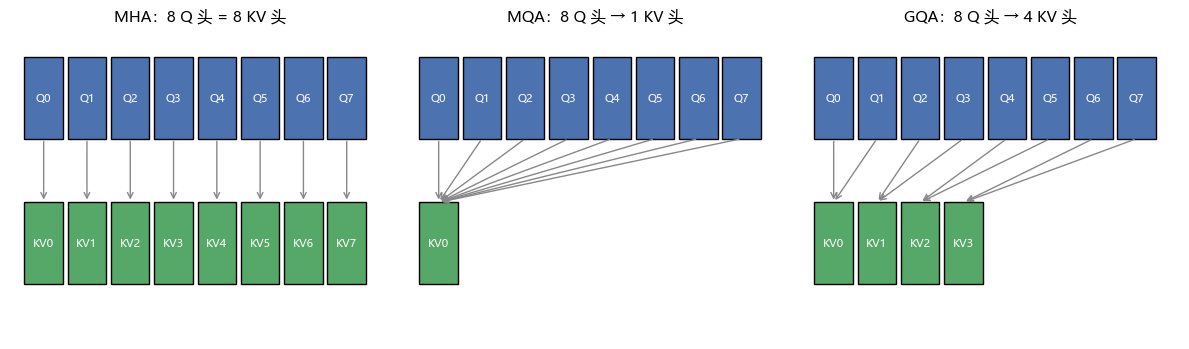

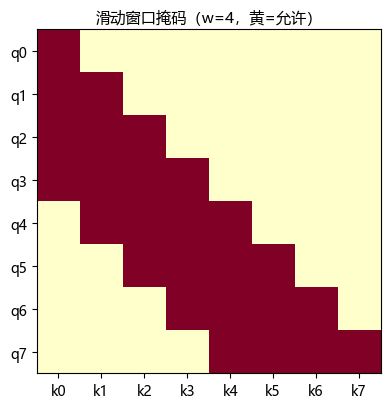

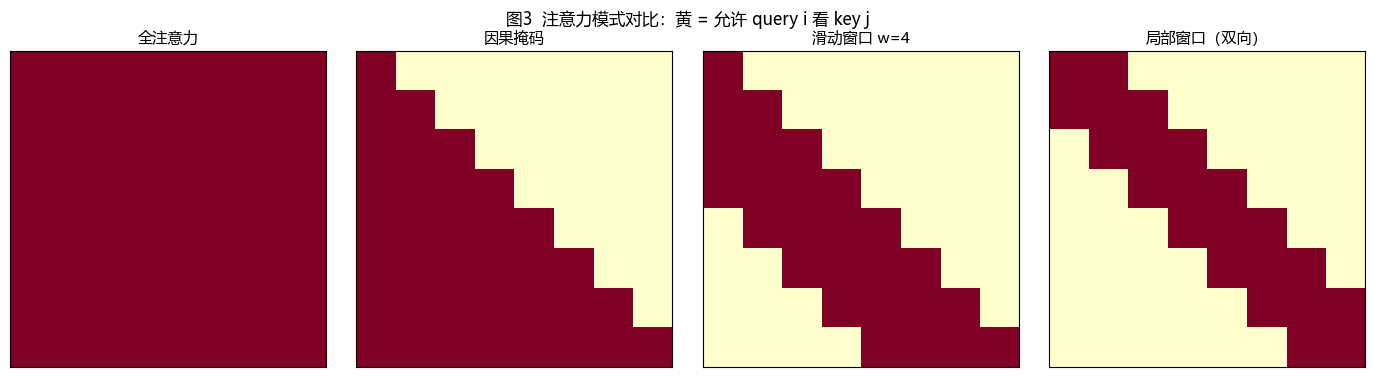

In [15]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

# ---- 图1：MHA / MQA / GQA 的 Q→KV 头映射 ----
fig, axes = plt.subplots(1, 3, figsize=(12, 3.6))
schemes = [
    ('MHA：8 Q 头 = 8 KV 头', [i for i in range(8)], 'MHA'),
    ('MQA：8 Q 头 → 1 KV 头', [0] * 8, 'MQA'),
    ('GQA：8 Q 头 → 4 KV 头', [i // 2 for i in range(8)], 'GQA'),
]
for ax, (title, kv_of_q, tag) in zip(axes, schemes):
    for qi in range(8):
        ax.add_patch(plt.Rectangle((qi * 0.9, 2.2), 0.8, 0.9, fc='#4C72B0', ec='k'))
        ax.text(qi * 0.9 + 0.4, 2.65, f'Q{qi}', ha='center', va='center', fontsize=8, color='white')
    for ki in sorted(set(kv_of_q)):
        ax.add_patch(plt.Rectangle((ki * 0.9, 0.6), 0.8, 0.9, fc='#55A868', ec='k'))
        ax.text(ki * 0.9 + 0.4, 1.05, f'KV{ki}', ha='center', va='center', fontsize=8, color='white')
    for qi in range(8):
        ki = kv_of_q[qi]
        ax.annotate('', xy=(ki * 0.9 + 0.4, 1.5), xytext=(qi * 0.9 + 0.4, 2.2),
                    arrowprops=dict(arrowstyle='->', color='#888', lw=1.0))
    ax.set_xlim(-0.3, 7.6); ax.set_ylim(0, 3.4); ax.axis('off')
    ax.set_title(title, fontsize=11)
plt.tight_layout(); plt.show()

# ---- 图2：滑动窗口掩码矩阵 ----
fig, ax = plt.subplots(figsize=(4.6, 4.2))
im = ax.imshow(~mask_swa, cmap='YlOrRd', vmin=0, vmax=1)
ax.set_xticks(range(T)); ax.set_yticks(range(T))
ax.set_xticklabels([f'k{j}' for j in range(T)])
ax.set_yticklabels([f'q{i}' for i in range(T)])
ax.set_title(f'滑动窗口掩码（w={w}，黄=允许）', fontsize=11)
plt.tight_layout(); plt.show()

# ---- 图3：四种注意力的"允许位置"模式对比 ----
fig, axes = plt.subplots(1, 4, figsize=(14, 3.8))
modes = [
    ('全注意力', np.zeros((T, T), dtype=bool)),
    ('因果掩码', np.triu(np.ones((T, T)), 1).astype(bool)),
    ('滑动窗口 w=4', mask_swa),
    ('局部窗口（双向）', ~(np.abs(np.arange(T)[:, None] - np.arange(T)[None, :]) < 2)),
]
for ax, (t, m) in zip(axes, modes):
    ax.imshow(~m, cmap='YlOrRd', vmin=0, vmax=1)
    ax.set_xticks([]); ax.set_yticks([])
    ax.set_title(t, fontsize=11)
fig.suptitle('图3  注意力模式对比：黄 = 允许 query i 看 key j', fontsize=12)
plt.tight_layout(); plt.show()


## 综合对比与总结

| 变种 | 一句话 | KV 头数 | 代价/收益 |
|---|---|---|---|
| MHA | 每 Q 头配 K/V | h | 质量基准，缓存大 |
| MQA | 全部 Q 共享 K/V | 1 | 缓存最小，质量略降 |
| GQA | 分组共享 K/V | g | 缓存省 g/h，质量近 MHA |
| SWA | 只看窗口 w | h | 计算 $O(Nw)$，视野受限 |
| Flash | 分块在线 softmax | h | 显存 $O(N)$，数值等价 |

**minLLM 对应位置**：`model/model_minimind.py` 的 `Attention` 类正是 **GQA**：
`num_attention_heads=8 / num_key_value_heads=4`，`n_rep = 8//4 = 2`，
用 `repeat_interleave` 复制 KV 头；`flash_attn=True` 时用 `F.scaled_dot_product_attention`（内部就是 Flash Attention）。
LLaMA2-70B 用 GQA（8/1 近似 MQA）、Mistral 用滑动窗口 + GQA、DeepSeek-V2 用 MLA（多头潜在注意力，GQA 的进阶版）。
